<a href="https://colab.research.google.com/github/bhavananamburi/oasis-infobyte-internship-/blob/main/Bhavana_task5_Predicting_House_Prices_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicting House Prices with Linear Regression**

**Loading the Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import  warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
import pandas as pd


In [ ]:
uploaded = files.upload()

df= pd.read_csv("Housing.csv")

Saving Housing.csv to Housing.csv


In [ ]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
df.shape

(545, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


**Data Cleaning**

In [ ]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
df.duplicated().sum()

np.int64(0)

**Correlation Heatmap**

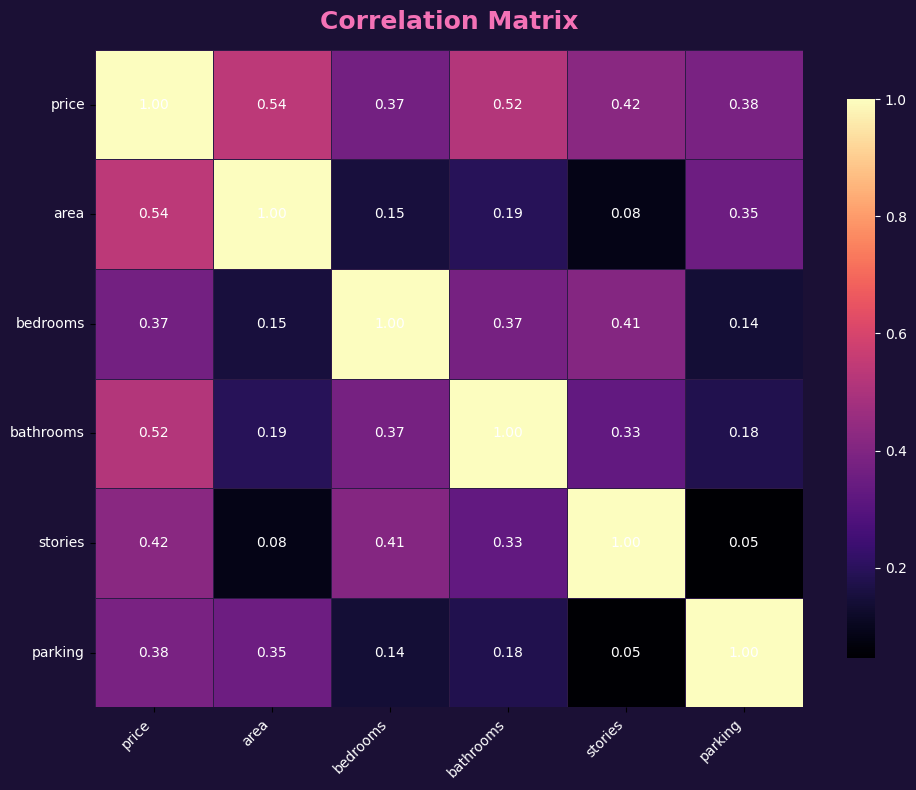

In [ ]:

plt.figure(figsize=(10,8), facecolor="#1B1035")

ax = sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="magma",
    linewidths=0.5,
    linecolor="#2E1A47",
    annot_kws={"size":10, "color":"white"},
    cbar_kws={"shrink":0.85}
)

ax.set_facecolor("#1B1035")

plt.title(
    "Correlation Matrix",
    fontsize=18,
    fontweight="bold",
    color="#F472B6",
    pad=15
)

plt.xticks(rotation=45, ha="right", fontsize=10, color="white")
plt.yticks(rotation=0, fontsize=10, color="white")

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors="white")

plt.tight_layout()
plt.show()

**Distribution of House Prices**

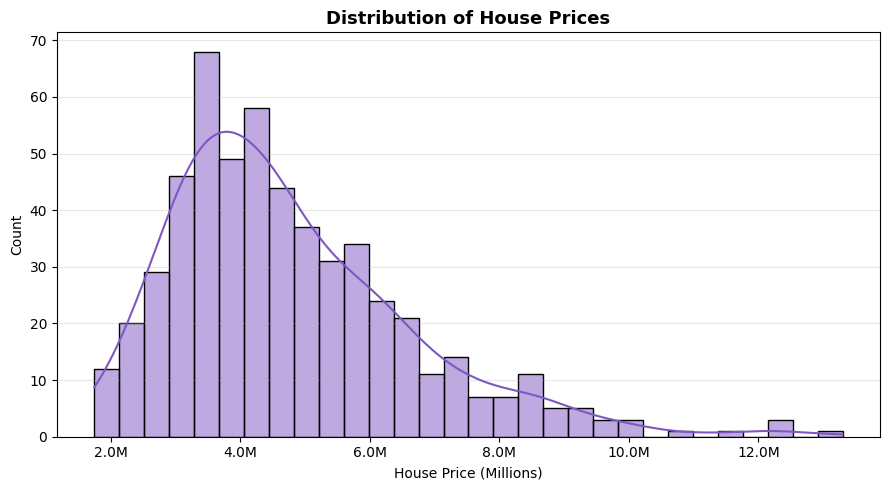

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

plt.figure(figsize=(9,5))

ax = sns.histplot(
    df['price'],
    bins=30,
    kde=True,
    color="#7E57C2",
    edgecolor="black"
)

ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)

plt.title("Distribution of House Prices", fontsize=13, fontweight="bold")
plt.xlabel("House Price (Millions)")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Price Outliers (Boxplot)**

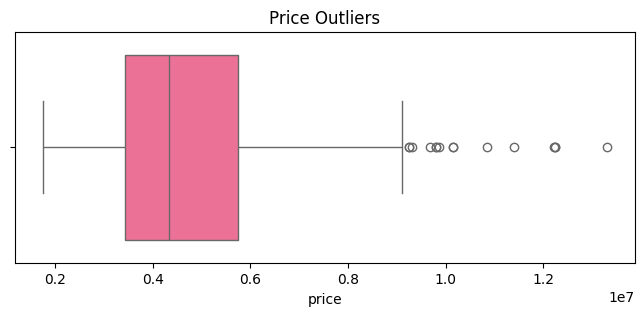

In [ ]:
plt.figure(figsize=(8,3))

sns.boxplot(
    x=df['price'],
    color='#FF5D8F'
)

plt.title("Price Outliers")

plt.show()

**Pair Plot**

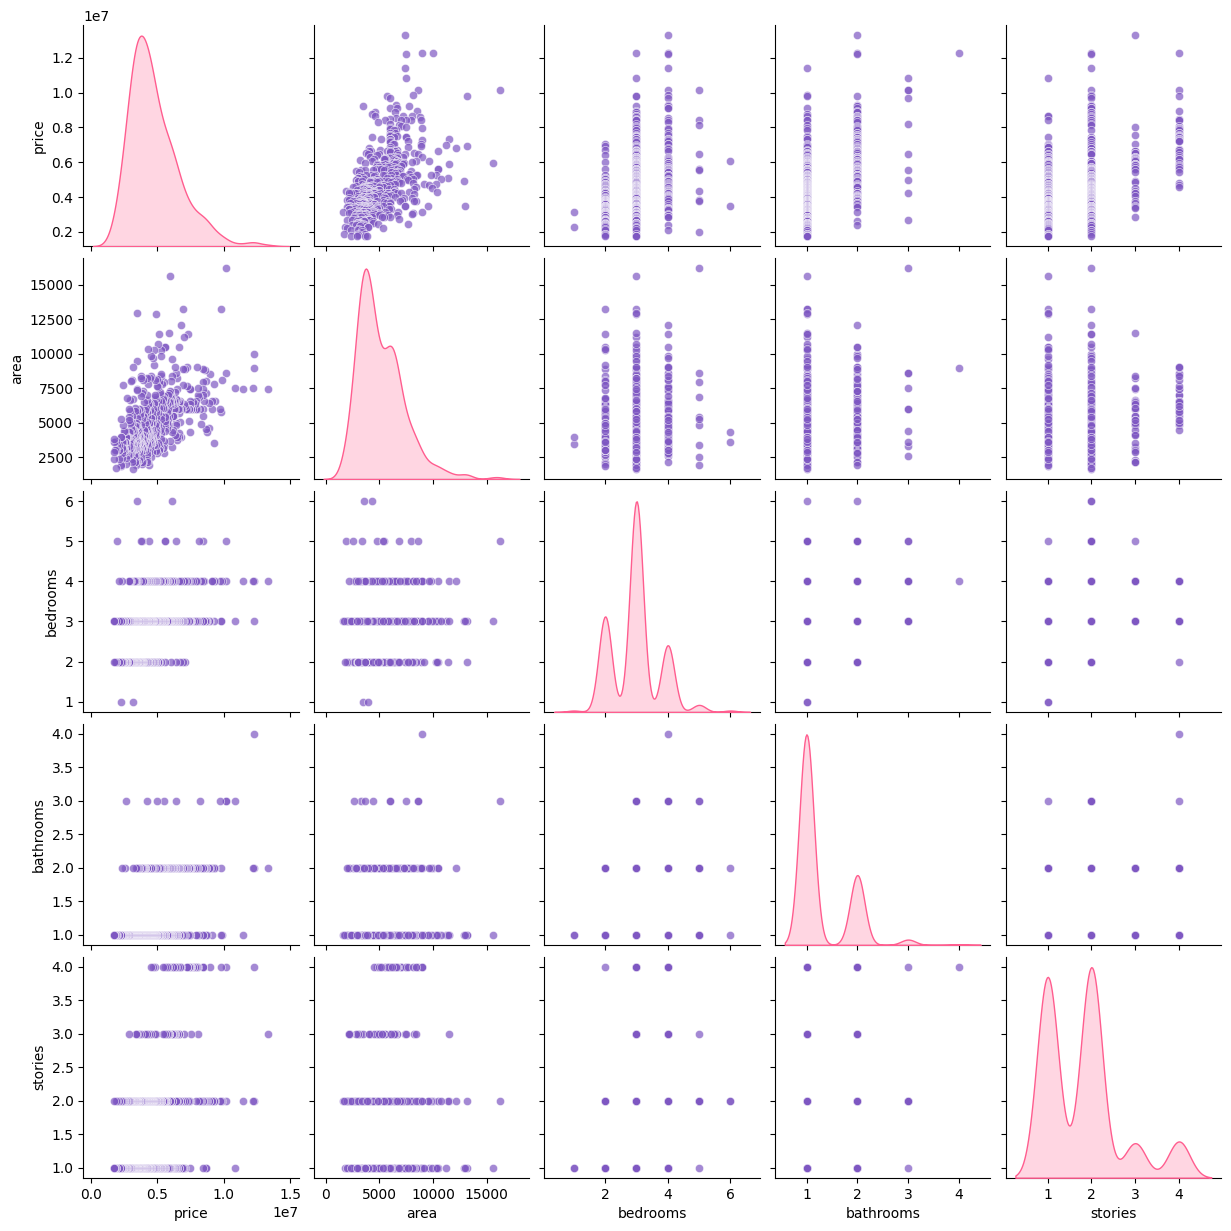

In [ ]:
sns.pairplot(
    df[['price', 'area', 'bedrooms', 'bathrooms', 'stories']],
    diag_kind='kde',
    plot_kws={
        'color': '#7E57C2',
        'alpha': 0.7,
        's': 35
    },
    diag_kws={
        'fill': True,
        'color': '#FF5D8F'
    }
)

plt.show()

**Area vs House Price**

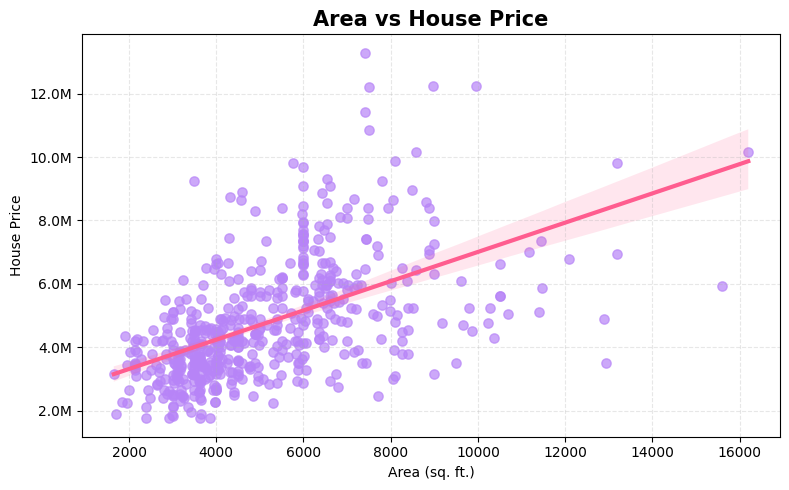

In [ ]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x='area',
    y='price',
    scatter_kws={
        'color': '#B784F7',
        'alpha': 0.7,
        's': 45
    },
    line_kws={
        'color': '#FF5D8F',
        'linewidth': 3
    }
)

plt.title(
    "Area vs House Price",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Area (sq. ft.)")
plt.ylabel("House Price")

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)

plt.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

**House Prices by Area animated**

In [ ]:
import plotly.express as px

fig = px.scatter(
    df,
    x="area",
    y="price",
    animation_frame="stories",
    color="stories",
    size="bathrooms",
    hover_name=df.index,
    hover_data={
        "bedrooms": True,
        "parking": True,
        "price": ":,.0f",
        "area": ":,.0f"
    },
    color_continuous_scale="RdPu",
    title="House Prices by Area animated"
)

fig.update_traces(
    marker=dict(
        line=dict(width=1, color="white"),
        opacity=0.8
    )
)

fig.update_layout(
    template="plotly_white",
    width=900,
    height=550,
    title_font=dict(size=22),
    xaxis_title="Area (sq. ft.)",
    yaxis_title="House Price",
    coloraxis_colorbar_title="Stories"
)

fig.show()

**Convert Yes/No Columns**

In [ ]:
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    df[col] = df[col].map({'yes':1,'no':0})

**Convert Furnishing Status**

In [ ]:
if 'furnishingstatus' in df.columns:
    df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)


# **Feature Selection and Data Preparation**

**Separate Features and Target**

In [ ]:
X = df.drop('price', axis=1)
y = df['price']

**Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Model Training**

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

**Prediction**

In [ ]:
y_pred = model.predict(X_test)

# **Model Evaluation**

Mean Absolute Error

In [ ]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 970043.4039201637


**Mean Squared Error**

In [ ]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 1754318687330.6633


**Root Mean Squared Error**

In [ ]:
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 1324506.9600914384


**R² Score**

In [ ]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.6529242642153185


In [ ]:
print(f"R² Score: {r2:.3f}")

if r2 >= 0.8:
    print("The model explains most of the variation in house prices and performs well.")
elif r2 >= 0.6:
    print("The model shows good predictive performance.")
else:
    print("The model has limited predictive performance.")

R² Score: 0.653
The model shows good predictive performance.


# **Visualization**

**Actual vs Predicted Prices**

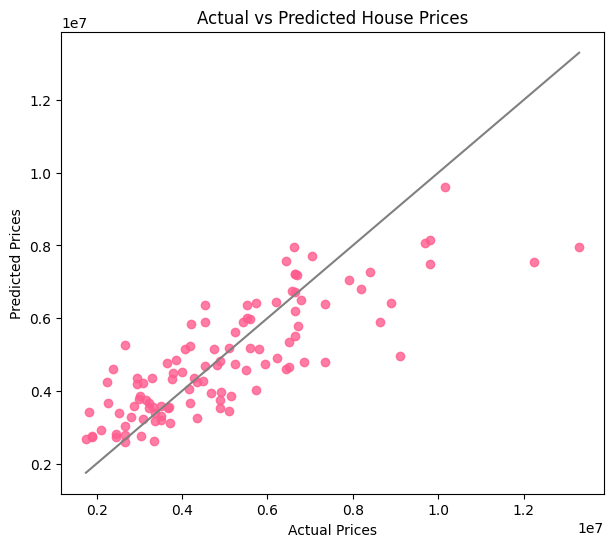

In [ ]:
plt.figure(figsize=(7,6))

plt.scatter(
    y_test,
    y_pred,
    color='#FF5D8F',
    alpha=0.8
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='grey'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

**Residual Plot**

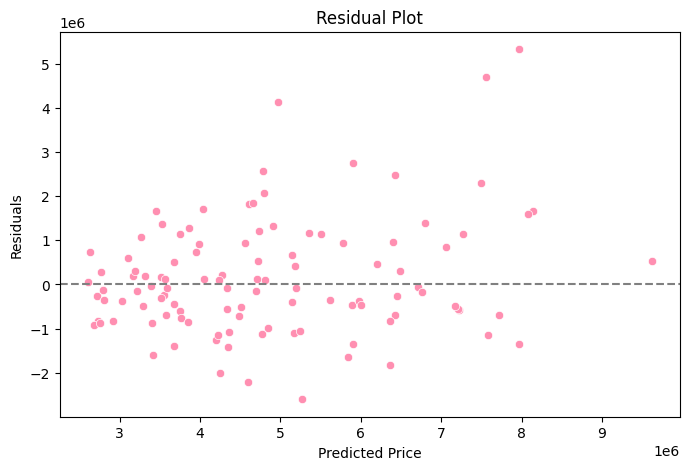

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=y_pred,
    y=residuals,
    color='#FF8FB1'
)

plt.axhline(
    y=0,
    color='grey',
    linestyle='--'
)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

**Feature Importance (Coefficients)**

In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

coefficients

,Feature,Coefficient
2,bathrooms,1.094445e+06
8,airconditioning,7.914267e+05
7,hotwaterheating,6.846499e+05
10,prefarea,6.298906e+05
3,stories,4.074766e+05
6,basement,3.902512e+05
4,mainroad,3.679199e+05
5,guestroom,2.316100e+05
9,parking,2.248419e+05
1,bedrooms,7.677870e+04


**Coefficient Bar Chart**

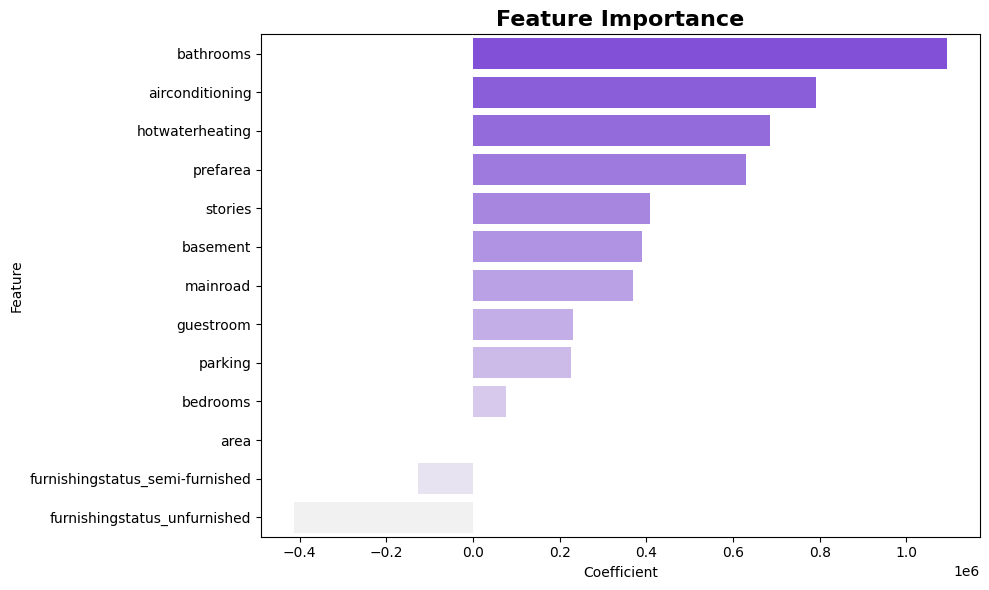

In [ ]:
palette = sns.light_palette("#7C3AED", n_colors=len(coefficients), reverse=True)

plt.figure(figsize=(10,6))

sns.barplot(
    data=coefficients,
    x='Coefficient',
    y='Feature',
    palette=palette
)

plt.title("Feature Importance", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

**HOUSE PRICE ANALYTICS DASHBOARD**

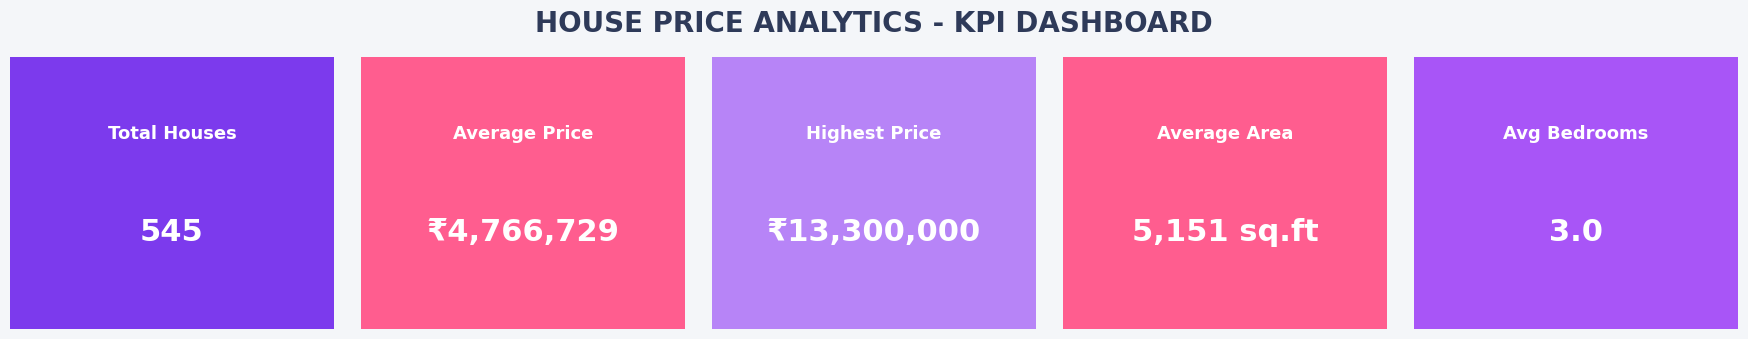

In [ ]:
import matplotlib.pyplot as plt

total_houses = len(df)
avg_price = df['price'].mean()
max_price = df['price'].max()
avg_area = df['area'].mean()
avg_bedrooms = df['bedrooms'].mean()

fig = plt.figure(figsize=(18,4), facecolor="#F4F6F9")

titles = [
    "Total Houses",
    "Average Price",
    "Highest Price",
    "Average Area",
    "Avg Bedrooms"
]

values = [
    f"{total_houses}",
    f"₹{avg_price:,.0f}",
    f"₹{max_price:,.0f}",
    f"{avg_area:,.0f} sq.ft",
    f"{avg_bedrooms:.1f}"
]

colors = [
    "#7C3AED",
    "#FF5D8F",
    "#B784F7",
    "#FF5D8F",
    "#A855F7"
]

for i in range(5):

    ax = fig.add_axes([0.02 + i*0.195, 0.18, 0.18, 0.68])

    ax.set_facecolor(colors[i])

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.text(
        0.5,
        0.72,
        titles[i],
        ha="center",
        va="center",
        fontsize=13,
        color="white",
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.36,
        values[i],
        ha="center",
        va="center",
        fontsize=22,
        color="white",
        fontweight="bold"
    )

fig.suptitle(
    "HOUSE PRICE ANALYTICS - KPI DASHBOARD",
    fontsize=20,
    fontweight="bold",
    color="#2E3A59"
)

plt.show()

**Overall Insights**

• Houses with a larger area generally have higher prices.

• Features such as bedrooms, bathrooms, stories and parking also influence house prices.

• The Linear Regression model predicted house prices with good accuracy.

• Feature importance analysis showed that some variables contribute more than others.

• The visualizations helped understand price patterns and relationships between housing features.
